# Machine Learning Lab 6 — Perceptron Learning Algorithm

**Name:** Hanshal Bobate  
**Section:** B  
**Roll No.:** 40  
**Batch:** B3

## Aim
To study the Seeds dataset, perform exploratory data analysis and preprocessing, and build and evaluate a neural-network classifier for predicting seed classes.

### Workflow
1. Import the required Python libraries.
2. Load and preview the Seeds dataset.
3. Inspect the dataset structure, descriptive statistics, and missing values.
4. Check for duplicate records and inspect feature distributions and potential outliers.
5. Explore the target-class distribution and relationships between features using visualizations.
6. Separate the input features and target labels, then encode the class labels.
7. Split the data into training and testing sets.
8. Standardize numerical features using the training data.
9. Build, compile, and train the neural-network classifier.
10. Visualize training progress and evaluate the model using classification metrics and a confusion matrix.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load the Dataset

Read `seeds_new.csv` into a Pandas DataFrame named `df`. The DataFrame is used throughout the analysis and model-building workflow.

In [ ]:
df = pd.read_csv('seeds_new.csv')

## Preview the Dataset

Display the first five rows to verify that the dataset loaded correctly and inspect the available measurements and class label.

In [ ]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## Exploratory Data Analysis (EDA)

EDA is performed before splitting or scaling the data to understand the dataset's structure, data quality, feature distributions, outliers, class balance, and relationships between features. These steps only inspect and visualize the data; they do not modify the dataset.

### 1. Preview the Dataset

### 1. Preview the Dataset

Display the first and last five records to inspect sample observations from both ends of the dataset.

In [ ]:
# Display the first and last five records to inspect representative observations.
display(df.head())
display(df.tail())

### 2. Understand the Dataset Structure

### 2. Understand the Dataset Structure

Check the number of rows and columns, list the column names, and inspect data types and non-null counts with `df.info()`.

In [ ]:
# Shape gives (rows, columns); columns lists feature and target names.
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()

### 3. Descriptive Statistics

### 3. Descriptive Statistics

Generate summary statistics for numerical columns, including count, mean, standard deviation, quartiles, and minimum/maximum values.

In [ ]:
# Summary statistics help reveal feature ranges, spread, and possible unusual values.
display(df.describe())

### 4. Check Missing Values

### 4. Check Missing Values

Count missing entries in each column and plot a heatmap to show where missing values occur. This step only inspects missingness; it does not impute or remove values.

In [ ]:
# Count missing values in each column and visualize their locations.
missing_counts = df.isnull().sum()
print("Missing values by column:")
display(missing_counts.to_frame(name="Missing Count"))

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values in Seeds Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### 5. Check Duplicate Records

### 5. Check Duplicate Records

Count exact duplicate rows so potential repeated records can be assessed. No records are deleted in this step.

In [ ]:
# Count duplicate rows without deleting them.
print("Number of duplicate rows:", df.duplicated().sum())

### 6. Identify Numerical Features and Inspect Distributions

### 6. Inspect Numerical Feature Distributions

Identify the target column and numerical input features, then plot histograms to examine the shape, spread, and possible skew of each feature distribution.

In [ ]:
# The Seeds dataset contains numerical measurements and a class label.
# Exclude the target from feature-distribution plots when it is present.
target_col = "Class (1, 2, 3)" if "Class (1, 2, 3)" in df.columns else df.columns[-1]
feature_df = df.drop(columns=[target_col], errors="ignore")
numeric_features = feature_df.select_dtypes(include=np.number).columns.tolist()
print("Target column:", target_col)
print("Numerical feature columns:", numeric_features)

if numeric_features:
    df[numeric_features].hist(figsize=(14, 10), bins=20, edgecolor="black")
    plt.suptitle("Feature Distributions in Seeds Dataset", y=1.02)
    plt.tight_layout()
    plt.show()

### 7. Detect Potential Outliers with Boxplots

### 7. Inspect Potential Outliers

Create boxplots for numerical features to highlight possible extreme observations. These are visual checks only; no outliers are removed during EDA.

In [ ]:
# Boxplots help visually identify observations that may be unusually far from the feature distributions.
# Potential outliers are inspected only; no rows are removed during EDA.
if numeric_features:
    ncols = 2
    nrows = int(np.ceil(len(numeric_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_features):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Boxplot of {col}")
    for ax in axes[len(numeric_features):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

### 8. Univariate Analysis of the Target Class

### 8. Analyze the Target Class

Count the observations in each seed class and visualize the class distribution. This helps reveal whether the classes are balanced.

In [ ]:
# Examine the number of observations in each seed class.
print("Class counts:")
display(df[target_col].value_counts(dropna=False).sort_index().to_frame(name="Count"))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target_col, order=sorted(df[target_col].dropna().unique()))
plt.title("Class Distribution in Seeds Dataset")
plt.xlabel("Seed Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 9. Bivariate Analysis: Features by Class

### 9. Compare Features Across Classes

Use grouped boxplots to compare each numerical feature across seed classes and inspect which measurements may help distinguish the classes.

In [ ]:
# Compare the distribution of each numerical measurement across seed classes.
# This can show which features may help distinguish the three classes.
if numeric_features:
    ncols = 2
    nrows = int(np.ceil(len(numeric_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_features):
        sns.boxplot(data=df, x=target_col, y=col, ax=ax)
        ax.set_title(f"{col} by Seed Class")
        ax.set_xlabel("Seed Class")
    for ax in axes[len(numeric_features):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

### 10. Multivariate Analysis: Correlation Matrix

### 10. Examine Feature Correlations

Calculate and visualize pairwise correlations among numerical input features. The class label is excluded so the heatmap focuses on relationships between measurements.

In [ ]:
# Correlation values summarize linear relationships between numerical columns.
# The class label is excluded so this heatmap focuses on relationships among measurements.
if len(numeric_features) >= 2:
    corr = df[numeric_features].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Matrix of Seed Measurements")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical feature columns to calculate a correlation matrix.")

## Prepare Input Features and Target

Separate the measurement columns (`X`) from the original class labels (`y_original`) and print their shapes to confirm the input and target dimensions.

In [ ]:
X = df.drop("Class (1, 2, 3)", axis = 1)
y_original = df['Class (1, 2, 3)']

print("Input Shape: ", X.shape)
print("Output Shape: ", y_original.shape)

Input Shape:  (210, 7)
Output Shape:  (210,)


## Encode the Target Labels

Convert class labels from 1–3 to 0–2 by subtracting one. This encoding matches the output indices produced by the neural network's three-unit softmax layer.

In [ ]:
y = y_original - 1
print("Original Classes: ")
print(sorted(y_original.unique()))
print("New Classes: ")
print(sorted(y.unique()))

Original Classes: 
[np.int64(1), np.int64(2), np.int64(3)]
New Classes: 
[np.int64(0), np.int64(1), np.int64(2)]


## Split the Dataset

Split the features and encoded labels into training and testing sets. The 80/20 split uses a fixed random seed for reproducibility and `stratify=y` to preserve class proportions.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

## Standardize the Features

Fit `StandardScaler` on the training features and use the fitted scaler to transform both training and test data. Fitting only on training data avoids leaking test-set statistics into training.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Additional Scaling Operation

This cell fits and applies a scaler directly to `X_test`. Note that the resulting array is not used by the model; the correctly transformed test data is already stored in `X_test_scaled` above.

In [ ]:
scaler.fit_transform(X_test)

array([[-0.13481356, -0.30885661,  1.63834475, -0.72108928,  0.28326462,
        -0.76430253, -1.20943602],
       [-0.86696115, -0.79265998, -1.079508  , -0.44412568, -1.01611436,
        -0.08296069, -0.1493714 ],
       [ 0.3031065 ,  0.49244271, -0.70339658,  0.66153059,  0.00779627,
        -0.80711315,  0.9685525 ],
       [-1.32882996, -1.4578896 , -0.42131302, -1.40250766, -1.05769449,
         0.74059948, -0.71763216],
       [ 1.23710786,  1.05184035,  1.89804073,  0.79121989,  1.36954545,
        -0.66416923,  1.14006393],
       [-0.46667485, -0.42224803, -0.31833013, -0.17155833, -0.40280748,
         2.38191499,  0.06140168],
       [ 2.15058173,  2.0799225 ,  0.78313902,  2.07492419,  1.98285233,
         0.67094153,  1.87157051],
       [ 0.37495276,  0.31101645,  1.0697001 ,  0.12079214,  0.53534414,
         1.33559449, -0.56678476],
       [ 1.65107916,  1.67171341,  0.42941519,  1.6418938 ,  1.48908831,
        -0.57346877,  1.60087175],
       [ 1.28842662,  1.2257

## Build the Neural Network

Define a sequential artificial neural network with seven input features, two ReLU hidden layers, and a three-unit softmax output layer for the three seed classes. Display the architecture summary.

In [ ]:
model = Sequential([
    Input(shape = (7,)),
    Dense(16, activation = 'relu'),
    Dense(8 , activation = 'relu'),
    Dense(3 , activation = 'softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

Configure the network with the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the training metric.

In [ ]:
model.compile(optimizer = Adam(learning_rate=0.001), loss = "sparse_categorical_crossentropy", metrics=['accuracy'])


## Specify the Loss Function

Store the sparse categorical cross-entropy loss name in a variable. The model has already been compiled with this loss above.

In [ ]:
loss = "sparse_categorical_crossentropy"


## Configure Early Stopping

Create an early-stopping callback that monitors validation loss and stops training after ten epochs without improvement, restoring the best-performing weights.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


## Train the Neural Network

Train the model on the scaled training set for up to 100 epochs, reserving 20% of the training data for validation and using early stopping to reduce unnecessary training.

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
    # ,verbose = True
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9254 - loss: 0.1783 - val_accuracy: 0.9706 - val_loss: 0.1624
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9254 - loss: 0.1769 - val_accuracy: 0.9706 - val_loss: 0.1628
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9254 - loss: 0.1749 - val_accuracy: 0.9706 - val_loss: 0.1645
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9254 - loss: 0.1729 - val_accuracy: 0.9706 - val_loss: 0.1659
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9254 - loss: 0.1709 - val_accuracy: 0.9412 - val_loss: 0.1674
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9254 - loss: 0.1692 - val_accuracy: 0.9118 - val_loss: 0.1686
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9254 - loss: 0.1674 - val_accuracy: 0.9118 - val_loss: 0.1691
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9254 - loss: 0.1664 - val_accuracy: 0.9118 - val_loss:

## Visualize Training Progress

Plot training and validation accuracy across epochs to compare learning progress and check for signs of overfitting. The y-axis represents accuracy, as indicated by the plotted values.

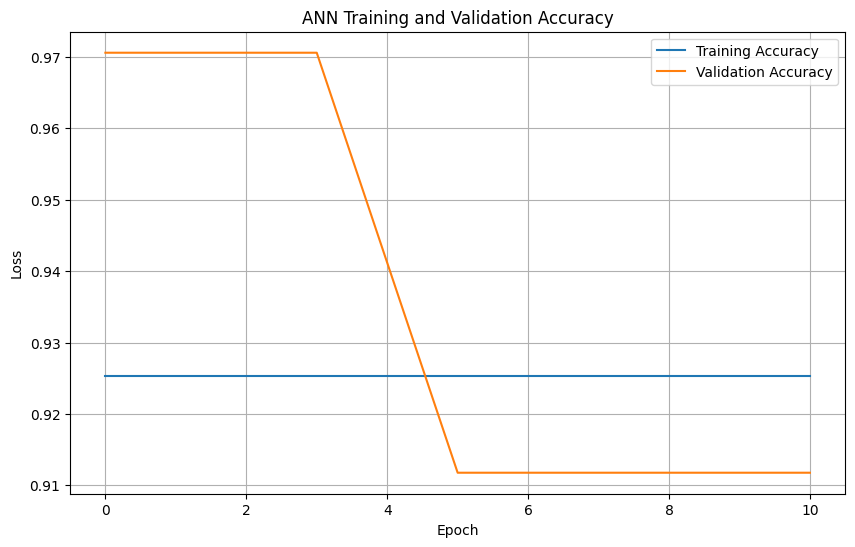

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Training and Validation Accuracy')
plt.legend()
plt.grid(1)
plt.show()

## Evaluate the Model on Test Data

Evaluate the trained model on the held-out test set and print its test accuracy and loss. The loss is a loss value, so it should not be interpreted as a percentage.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8810 - loss: 0.2555
Test Accuracy: 88.10%
Test Loss: 25.55%


## Generate Predictions

Predict class probabilities for the test set, then use `argmax` to select the class with the highest probability for each observation. The printed predictions are still in encoded form (0–2).

In [ ]:
y_prob = model.predict(X_test_scaled, verbose = True)
print(y_prob[:5])
y_pred = np.argmax(y_prob, axis=1)
print()
print("Predicted encoded Classes: ")
print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[9.06602085e-01 1.36398012e-02 7.97581598e-02]
 [8.32178071e-02 5.38138382e-04 9.16244030e-01]
 [3.37589771e-01 6.43569052e-01 1.88411493e-02]
 [1.30061265e-02 4.85827286e-06 9.86989021e-01]
 [1.69817377e-02 9.81758296e-01 1.25996128e-03]]

Predicted encoded Classes: 
[0 2 1 2 1 2 1 1 1 1]


## Restore Original Class Labels

Add one to the encoded predictions and test labels to convert them back to the dataset's original class labels (1–3) for easier interpretation.

In [ ]:
y_pred_original = y_pred+1
y_test_original = y_test+1


## Compare Actual and Predicted Classes

Create a DataFrame containing the original actual and predicted class labels, then display the first ten comparisons.

In [ ]:
comparision = pd.DataFrame({'Actual Class:': y_test_original.values, 'Predicted Class:': y_pred_original})
comparision.head(10)

,Actual Class:,Predicted Class:
0,1,1
1,3,3
2,2,2
3,3,3
4,2,2
5,3,3
6,2,2
7,1,2
8,2,2
9,2,2


## Calculate Accuracy

Compute accuracy, the proportion of test observations whose predicted class matches the actual class.

In [ ]:
accuracy = accuracy_score(y_test_original, y_pred_original)
print("Accuracy: ", accuracy)

Accuracy:  0.8809523809523809


## Calculate Precision

Calculate weighted precision, which combines class-level precision scores while accounting for the number of true observations in each class.

In [ ]:
precision = precision_score(y_test_original, y_pred_original, average='weighted')
print("Precision: ", precision)

Precision:  0.8995098039215687


## Calculate Recall

Calculate weighted recall, which measures how well the model identifies observations belonging to each class while accounting for class support.

In [ ]:
recall = recall_score(y_test_original, y_pred_original, average='weighted')
print("Recall: ", recall)

Recall:  0.8809523809523809


## Calculate the F1 Score

Calculate weighted F1, the weighted combination of precision and recall. The print label currently says `Precision`; the reported value is actually the F1 score.

In [ ]:
f1 = f1_score(y_test_original, y_pred_original, average='weighted')
print("Precision: ", f1)

Precision:  0.8730559451457066


## Summarize Evaluation Metrics

Collect accuracy, weighted precision, weighted recall, and weighted F1 into a single DataFrame for convenient comparison.

In [ ]:
metrics = pd.DataFrame({'Accuracy': [accuracy], 'Precision': [precision], 'Recall': [recall], 'F1 Score': [f1]})
metrics.head()

,Accuracy,Precision,Recall,F1 Score
0,0.880952,0.89951,0.880952,0.873056


## View the Classification Report

Print per-class precision, recall, F1 score, and support, along with the overall averages for the test predictions.

In [ ]:
print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

           1       1.00      0.64      0.78        14
           2       0.82      1.00      0.90        14
           3       0.88      1.00      0.93        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



## Calculate the Confusion Matrix

Count correct and incorrect predictions for each actual/predicted class combination. Rows represent actual classes and columns represent predicted classes.

In [ ]:
cm = confusion_matrix(y_test_original, y_pred_original)
print(cm)

[[ 9  3  2]
 [ 0 14  0]
 [ 0  0 14]]


## Visualize the Confusion Matrix

Display the confusion matrix as a heatmap with cell counts. The diagonal contains correct predictions; off-diagonal cells show misclassifications.

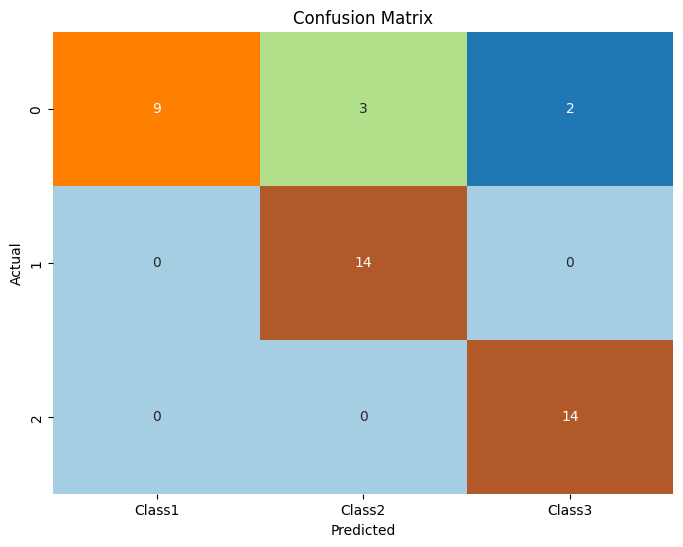

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Paired', xticklabels=["Class1","Class2","Class3"],cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()